In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_cleaned.xlsx to dataset_cleaned (2).xlsx


In [ ]:
print(uploaded.keys())

dict_keys(['dataset_cleaned (2).xlsx'])


In [22]:
import pandas as pd
df = pd.read_excel('dataset_cleaned (2).xlsx', engine='openpyxl')
print(df.shape)
print(df.columns.tolist())

(51290, 24)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [ ]:
print("Shape:", df.shape)

print("\nColumns:", df.columns.tolist())

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

Shape: (51290, 24)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']

Data Types:
 Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code        object
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

Missing Value

In [ ]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,22638.480000,14.000000,0.850000,8399.976000,933.570000


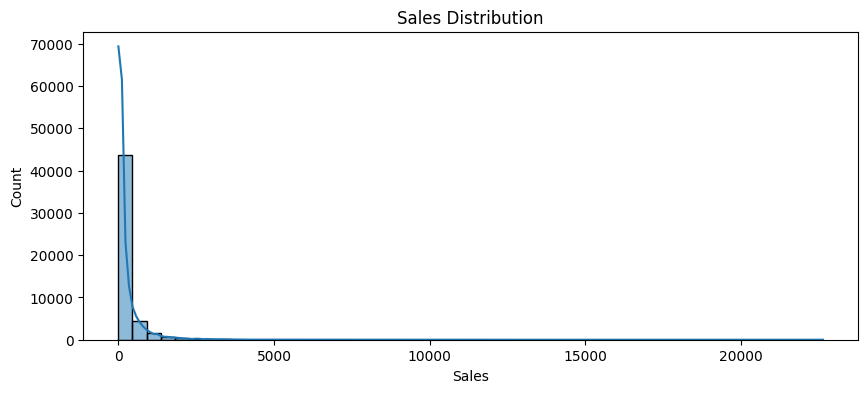

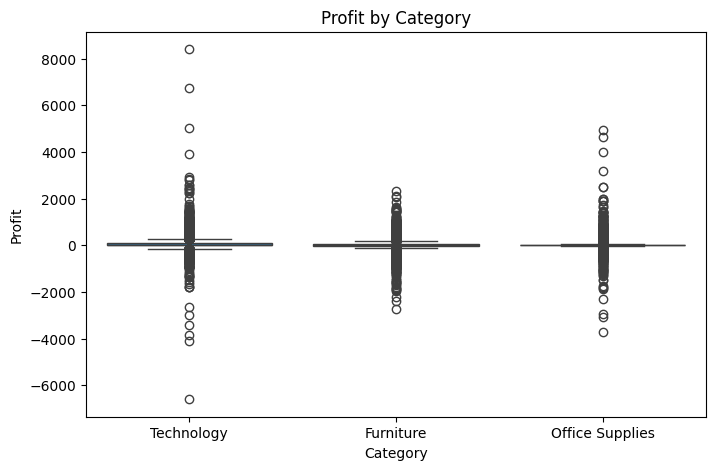

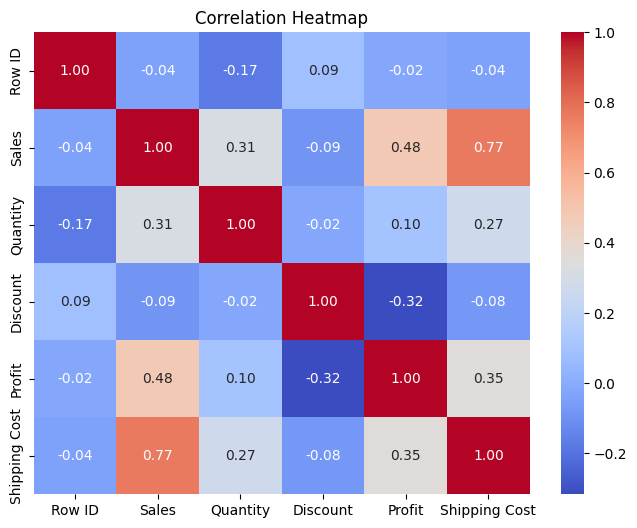

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Sales Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Profit', data=df)
plt.title('Profit by Category')
plt.show()

plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Profit'] < lower) | (df['Profit'] > upper)]
print(f"Number of outliers: {len(outliers)}")
print(f"Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")

Number of outliers: 9755
Lower Bound: -55.22, Upper Bound: 92.03
